In [1]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)
print(torch.cuda.is_available())

2.8.0+cpu
0.23.0+cpu
False


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# -------------------------
# 1. Paths
# -------------------------
train_dir = r"C:\Users\A75\Downloads\archive\Skin cancer ISIC The International Skin Imaging Collaboration\Train"
test_dir  = r"C:\Users\A77\Downloads\archive\Skin cancer ISIC The International Skin Imaging Collaboration\Test"


In [5]:
from torchvision import transforms

train_transforms_resnet = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms_resnet = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
#train_loader 

# -------------------------
# 3. Load datasets
# -------------------------


# it works like this when image classification is present in form of folders
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms_resnet)
test_dataset  = datasets.ImageFolder(root=test_dir, transform=test_transforms_resnet)






#splitting the data into validation and training 
from torch.utils.data import random_split
val_ratio = 0.2

train_size = int((1 - val_ratio) * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

val_data.dataset.transform = test_transforms_resnet




# -------------------------
# 4. Create DataLoaders
# -------------------------
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# -------------------------
# 5. Check
# -------------------------
print("Classes:", train_dataset.classes)
print("Train samples:", len(train_data))
print("Val samples:", len(val_data))
print("Test samples:", len(test_dataset))

Classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Train samples: 1791
Val samples: 448
Test samples: 118


In [7]:
#RESNET 18 MODEL

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

modelnet = models.resnet50(weights='IMAGENET1K_V1')

# Replace final layer
num_features = modelnet.fc.in_features

modelnet.fc = nn.Linear(num_features, 9)

modelnet = modelnet.to(device)

cpu
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\A7517/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


In [8]:
# 4. Optimizer

# Use lower learning rate:
import torch.optim as optim
optimizer = torch.optim.AdamW(modelnet.parameters(), lr=1e-4, weight_decay=1e-4)

In [10]:
# 3. Weighted loss (VERY IMPORTANT)

# Your dataset is imbalanced.

# Use weighted loss:
from collections import Counter

class_counts = Counter(train_dataset.targets)
print(class_counts)

total_samples = sum(class_counts.values())

weights = []

for i in range(len(train_dataset.classes)):
    weights.append(total_samples / class_counts[i])

weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

Counter({5: 462, 3: 438, 1: 376, 4: 357, 7: 181, 8: 139, 0: 114, 2: 95, 6: 77})


In [11]:
epochs = 25
best_acc = 0.0

# -------------------------
# Scheduler (ADD THIS)
# -------------------------
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    modelnet.train()
    train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = modelnet(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    # ---------------- VALIDATION ----------------
    modelnet.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = modelnet(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    # ---------------- PRINT ----------------
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

    # ---------------- SAVE BEST MODEL ----------------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(modelnet.state_dict(), "best_model.pth")

    # ---------------- SCHEDULER STEP (ADD THIS) ----------------
    scheduler.step()

Epoch [1/25] Train Loss: 1.6828 Val Loss: 1.4326 Val Acc: 64.51%
Epoch [2/25] Train Loss: 1.1460 Val Loss: 1.3843 Val Acc: 57.59%
Epoch [3/25] Train Loss: 0.9623 Val Loss: 1.4659 Val Acc: 62.28%
Epoch [4/25] Train Loss: 0.8814 Val Loss: 1.4732 Val Acc: 66.07%
Epoch [5/25] Train Loss: 0.8308 Val Loss: 1.5257 Val Acc: 67.86%
Epoch [6/25] Train Loss: 0.8074 Val Loss: 1.5237 Val Acc: 66.07%
Epoch [7/25] Train Loss: 0.7986 Val Loss: 1.6303 Val Acc: 65.18%
Epoch [8/25] Train Loss: 0.7821 Val Loss: 1.5257 Val Acc: 69.64%
Epoch [9/25] Train Loss: 0.7672 Val Loss: 1.6336 Val Acc: 69.42%
Epoch [10/25] Train Loss: 0.7688 Val Loss: 1.6374 Val Acc: 69.64%
Epoch [11/25] Train Loss: 0.7552 Val Loss: 1.6233 Val Acc: 68.30%
Epoch [12/25] Train Loss: 0.7594 Val Loss: 1.6513 Val Acc: 69.64%
Epoch [13/25] Train Loss: 0.7498 Val Loss: 1.6799 Val Acc: 68.97%
Epoch [14/25] Train Loss: 0.7519 Val Loss: 1.6642 Val Acc: 70.76%
Epoch [15/25] Train Loss: 0.7516 Val Loss: 1.6859 Val Acc: 70.31%
Epoch [16/25] Train

KeyboardInterrupt: 

In [13]:
modelnet.eval()

correct = 0
total = 0

val_loss = 0.0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = modelnet(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Testing Loss: {val_loss/len(test_loader):.4f}")
print(f" Testing Accuracy: {accuracy:.2f}%")

Testing Loss: 1.8324
 Testing Accuracy: 58.47%


In [34]:
images, label = next(iter(test_loader))
img = images[11]
img = img.unsqueeze(0)
print(img.shape)
label[11]

torch.Size([1, 3, 224, 224])


tensor(0)

In [35]:
output = modelnet(img)
print(output)

pred = output.argmax(dim=1)

print(pred)

tensor([[-0.3154, -1.3831,  0.2803, -2.2353,  3.9415, -1.3827,  0.1090, -0.6560,
         -0.7630]], grad_fn=<AddmmBackward0>)
tensor([4])


In [36]:
#WORKING ON CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

modelnet.eval()

with torch.no_grad():
    for images, labels in test_loader:
        # images = images.to(device)
        # labels = labels.to(device)

        outputs = modelnet(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [37]:
cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[ 3  1  0  0 10  1  0  1  0]
 [ 0 15  0  0  0  1  0  0  0]
 [ 0  2 10  1  1  2  0  0  0]
 [ 0  0  0  2 12  2  0  0  0]
 [ 0  0  0  0 15  1  0  0  0]
 [ 1  2  0  0  0 13  0  0  0]
 [ 0  0  0  3  0  0  0  0  0]
 [ 0  3  1  2  0  2  0  8  0]
 [ 0  0  0  0  0  0  0  0  3]]


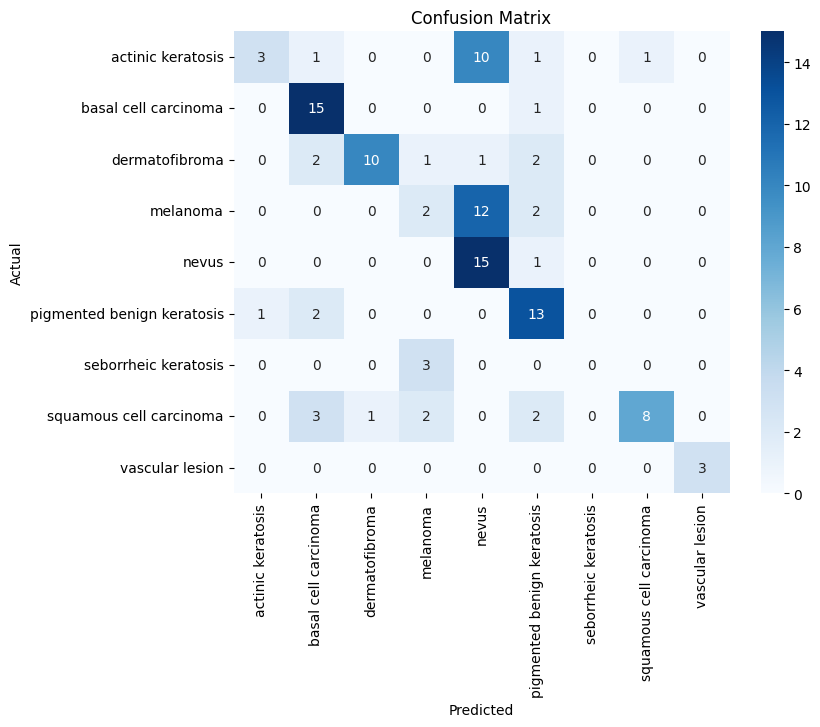

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

                            precision    recall  f1-score   support

         actinic keratosis       0.75      0.19      0.30        16
      basal cell carcinoma       0.65      0.94      0.77        16
            dermatofibroma       0.91      0.62      0.74        16
                  melanoma       0.25      0.12      0.17        16
                     nevus       0.39      0.94      0.56        16
pigmented benign keratosis       0.59      0.81      0.68        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.89      0.50      0.64        16
           vascular lesion       1.00      1.00      1.00         3

                  accuracy                           0.58       118
                 macro avg       0.60      0.57      0.54       118
              weighted avg       0.63      0.58      0.55       118



c:\Users\A7517\pytorch_projects\venv_isic\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\A7517\pytorch_projects\venv_isic\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\A7517\pytorch_projects\venv_isic\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

IMPROVEMENT INSTEAD OF USING RANDOM SPLIT WHICH SPLITS DATASET RANDOMLY, SO SOME CLASSES WOULD BE MISSING SO INSTEAD USE TRAIN TEST SPLIT TO TAKE CARE OF ALL CLASSES OF IMAGES 

Add WeightedRandomSampler

This may improve minority-class generalization.